In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter
import seaborn as sns

sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='matplotlib')

In [77]:
t = pd.read_csv("../data/kp_te_merged.tsv", sep="\t")
p = pd.read_csv("../data/kp_ridge.txt", sep="\t")

tp = pd.read_csv("../data/pa_te_merged.tsv", sep="\t")
pp = pd.read_csv("../data/pa_ridge.txt", sep="\t")

te = pd.read_csv("../te_merged.tsv", sep="\t")
pe = pd.read_csv("../data/ec_ridge_prediction.txt", sep="\t")

In [78]:
def get_transmission(df):
    df = df.iloc[1:].copy()

    # reshape to long format
    df_long = pd.concat([
        df[["sample1", "transmission_180d", "snps"]]
        .rename(columns={"sample1": "sample"}),
        df[["sample2", "transmission_180d", "snps"]]
        .rename(columns={"sample2": "sample"})
    ], ignore_index=True)

    df_long = df_long.dropna(subset=["sample"])
    
    df_long["snps"] = pd.to_numeric(df_long["snps"], errors="coerce")
    df_long["transmission_180d"] = pd.to_numeric(df_long["transmission_180d"], errors="coerce")

    def choose_row(g):
        g1 = g[g["transmission_180d"] == 1]
        if len(g1) > 0:
            row = g1.loc[g1["snps"].idxmin()]
        else:
            row = g.loc[g["snps"].idxmin()]
        return pd.Series({
            "transmission": row["transmission_180d"],
            "snps": row["snps"]
        })

    result = df_long.groupby("sample").apply(choose_row).reset_index()

    return result

In [79]:
tt = get_transmission(t)
tpt = get_transmission(tp)
tet = get_transmission(te)

In [80]:
tet

,sample,transmission,snps
0,SH238x04,0,464
1,SH238x06,0,167
2,SH238x07,0,630
3,SH238x17,0,242
4,SH238x23,0,217
...,...,...,...
1385,SH331x80,1,4
1386,SH331x81,0,123
1387,SH331x84,0,137
1388,SH331x85,0,1113


In [81]:
tt.rename(columns={"sample":"Sample", "tranmission":"Transmission"}, inplace=True)
tpt.rename(columns={"sample":"Sample", "tranmission":"Transmission"}, inplace=True)
tet.rename(columns={"sample":"Sample", "tranmission":"Transmission"}, inplace=True)

In [82]:
ttp = pd.merge(tt, p, on="Sample")
tptpp = pd.merge(tpt, pp, on="Sample")
tetpp = pd.merge(tet, pe, on="Sample")

In [83]:
ttp["Prediction"] = ttp["Prediction"].astype(int)
tptpp["Prediction"] = tptpp["Prediction"].astype(int)
tetpp["Prediction"] = tetpp["Prediction"].astype(int)

In [108]:
ttp["Prediction"].value_counts()

0    297
Name: Prediction, dtype: int64

In [109]:
tptpp["Prediction"].value_counts()

0    353
1      1
Name: Prediction, dtype: int64

In [105]:
tetpp["Prediction"].value_countsounts()

0    1390
Name: Prediction, dtype: int64

In [85]:
def plot_transmission_probability(df, title="", sp=""):
    """
    Plots transmission (y) vs probability (x),
    color-coded by prediction.
    """
    
    plt.figure(figsize=(7, 3))
    
    sns.scatterplot(
        data=df,
        x="Probability",
        y="transmission",
        hue="Prediction",
        palette="Set1",
        alpha=0.7
    )
    
    plt.xlabel("Probability")
    plt.ylabel("Transmission")
    plt.title(title)
    plt.yticks([0, 1])
    plt.ylim(-0.5, 1.5)
    
    plt.legend(title="Prediction", facecolor="white", framealpha=1)
    plt.tight_layout()
    
    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

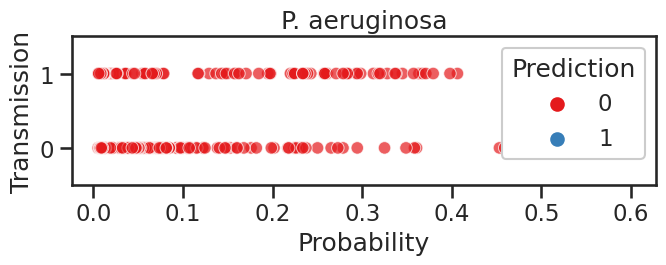

In [86]:
plot_transmission_probability(tptpp, title="P. aeruginosa", sp="pa")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

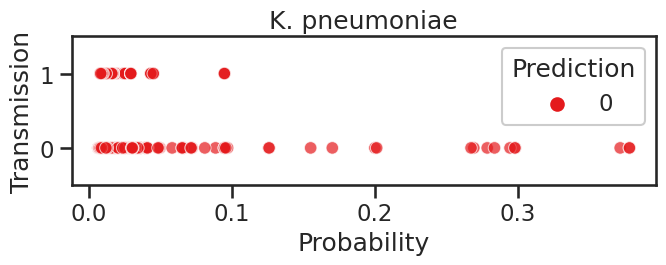

In [87]:
plot_transmission_probability(ttp, title="K. pneumoniae")

In [88]:
def plot_transmission_snps(df, title="", sp=""):

    df = df.copy()

    # Ensure numeric
    df["snps"] = pd.to_numeric(df["snps"], errors="coerce")
    df = df.dropna(subset=["snps"])

    df_sorted = df.sort_values("snps")

    plt.figure(figsize=(5,5))

    # Background points
    sns.scatterplot(
        data=df_sorted[df_sorted["transmission"] == 0],
        x="Probability",
        y="snps",
        color="xkcd:teal",
        alpha=0.7,
        s=100,
        label="Sporadic"
    )

    # Transmission points
    sns.scatterplot(
        data=df_sorted[df_sorted["transmission"] == 1],
        x="Probability",
        y="snps",
        color="xkcd:orange",
        alpha=0.7,
        s=100,
        label="Epidemic"
    )

    plt.xlabel("Predicted probability of transmission")
    plt.ylabel("Number of SNP")

    # Italic title
    plt.title(title, fontstyle="italic")

    # Axis limits
    plt.xlim(-0.1, 1)

    # Cleaner y-ticks
    yticks = np.linspace(0, df_sorted["snps"].max(), 5)
    plt.yticks(np.round(yticks, 0))


    # Legend formatting
    leg = plt.legend(frameon=True)
    leg.get_frame().set_facecolor("white")
    leg.get_frame().set_edgecolor("black")

    plt.tight_layout()
    
    plt.savefig(f'../out/figures/prediction_{sp}.png',
                dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../out/figures/prediciton_{sp}.svg',
                dpi=300, bbox_inches='tight', transparent=True, format='svg')
    
    plt.show()

In [89]:
from scipy.stats import mannwhitneyu

In [126]:
def plot_transmission_probability_strip_multi(tetpp, ttp, tptpp, pseudocount=0.001):

    dfs = [
        (tetpp, "E. coli"),
        (ttp, "K. pneumoniae"),
        (tptpp, "P. aeruginosa")
    ]

    fig, axes = plt.subplots(1, 3, figsize=(10,5), sharey=True)

    for ax, (df, title) in zip(axes, dfs):

        df = df.copy()

        # Ensure numeric
        df["Probability"] = pd.to_numeric(df["Probability"], errors="coerce")
        df = df.dropna(subset=["Probability"])

        # Add pseudocount
        df["Probability_pc"] = df["Probability"] + pseudocount

        # Map labels
        df["Transmission_Label"] = df["transmission"].map({
            0: "Sporadic",
            1: "Epidemic"
        })

        df["Transmission_Label"] = pd.Categorical(
            df["Transmission_Label"],
            categories=["Sporadic", "Epidemic"],
            ordered=True
        )

        # Stripplot
        sns.stripplot(
            data=df,
            x="Transmission_Label",
            y="Probability_pc",
            jitter=0.25,
            palette={"Sporadic":"xkcd:teal", "Epidemic":"xkcd:orange"},
            size=7,
            alpha=0.7,
            ax=ax
        )

        # Boxplot overlay
        sns.boxplot(
            data=df,
            x="Transmission_Label",
            y="Probability_pc",
            showcaps=False,
            boxprops={'facecolor':'None'},
            showfliers=False,
            whiskerprops={'linewidth':0},
            ax=ax,
            zorder=10
        )

        ax.set_yscale("log")
        ax.set_title(title, fontstyle="italic")
        ax.set_xlabel("")

    axes[0].set_ylabel("Transmission probability (log₁₀)")
    axes[1].set_ylabel("")
    axes[2].set_ylabel("")

    # Global y limits (adjust if desired)
    plt.ylim(8e-3, 0.7)

    plt.tight_layout()

    plt.savefig('../out/figures/probability_strip_all_species.png',
                dpi=300, bbox_inches='tight', transparent=True)

    plt.savefig('../out/figures/probability_strip_all_species.svg',
                dpi=300, bbox_inches='tight', transparent=True)

    plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

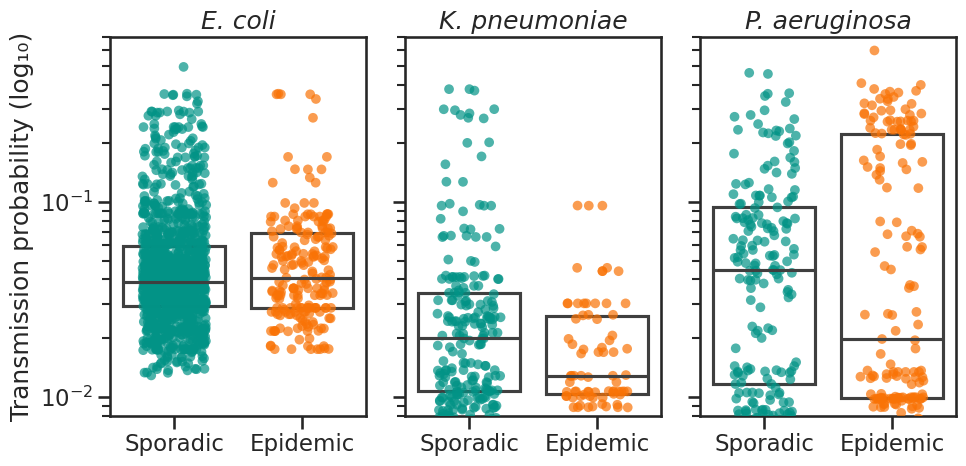

In [127]:
plot_transmission_probability_strip_multi(tetpp, ttp, tptpp)

In [122]:
def plot_transmission_probability_strip(df, title="", sp="", pseudocount=0.001):
    df = df.copy()

    # Ensure numeric
    df["Probability"] = pd.to_numeric(df["Probability"], errors="coerce")
    df = df.dropna(subset=["Probability"])

    # Add pseudocount to avoid log(0)
    df["Probability_pc"] = df["Probability"] + pseudocount

    # Map transmission to categorical labels
    df["Transmission_Label"] = df["transmission"].map({0: "Sporadic", 1: "Epidemic"})

    # Ensure order
    df["Transmission_Label"] = pd.Categorical(
        df["Transmission_Label"], 
        categories=["Sporadic", "Epidemic"], 
        ordered=True
    )

    plt.figure(figsize=(4,5))

    # Stripplot
    sns.stripplot(
        data=df,
        x="Transmission_Label",
        y="Probability_pc",
        jitter=0.25,
        palette={"Sporadic":"xkcd:teal", "Epidemic":"xkcd:orange"},
        size=8,
        alpha=0.7
    )

    # Boxplot overlay
    sns.boxplot(
        data=df,
        x="Transmission_Label",
        y="Probability_pc",
        showcaps=False,
        boxprops={'facecolor':'None'},
        showfliers=False,
        whiskerprops={'linewidth':0},
        zorder=10
    )

    plt.yscale("log")
    
    plt.ylim(8e-3, 0.6)

    plt.ylabel("Transmission probability (log₁₀)")
    plt.xlabel("")
    plt.title(title, fontstyle="italic")

    # Log scale limits
    #plt.ylim(pseudocount, 1)

    plt.tight_layout()

    # Save figures
    plt.savefig(f'../out/figures/probability_strip_{sp}.png', dpi=300, bbox_inches='tight', transparent=True)
    plt.savefig(f'../out/figures/probability_strip_{sp}.svg', dpi=300, bbox_inches='tight', transparent=True, format='svg')

    plt.show()

In [91]:
pwd

'/fast-storage/judit/predictions/workflow'

In [92]:
tptpp["transmission"].value_counts()

0    189
1    165
Name: transmission, dtype: int64

In [93]:
ttp["transmission"].value_counts()

0    223
1     74
Name: transmission, dtype: int64

In [94]:
tetpp["transmission"].value_counts()

0    1187
1     203
Name: transmission, dtype: int64

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

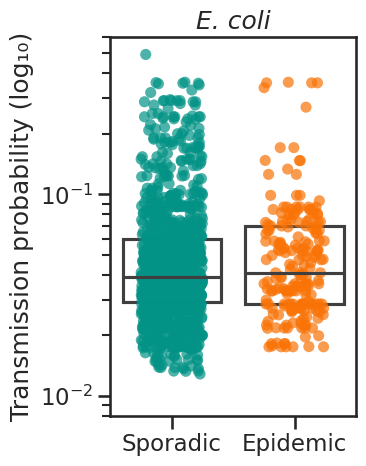

In [123]:
plot_transmission_probability_strip(tetpp, title="E. coli", sp="ec")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

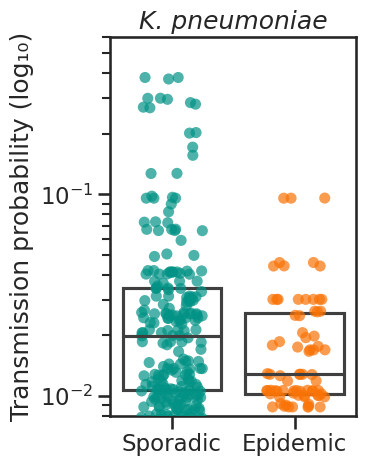

In [124]:
plot_transmission_probability_strip(ttp, title="K. pneumoniae", sp="kp")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

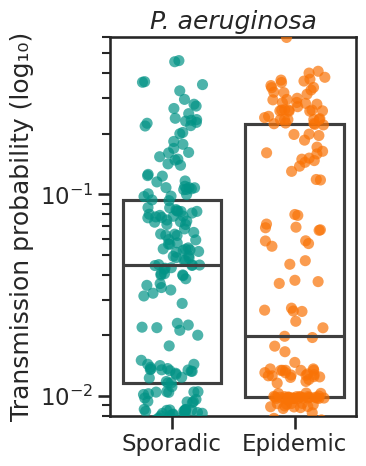

In [125]:
plot_transmission_probability_strip(tptpp, title="P. aeruginosa", sp="pa")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

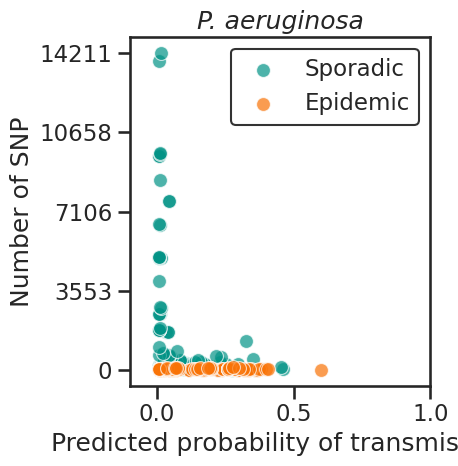

In [98]:
plot_transmission_snps(tptpp, title="P. aeruginosa", sp="pa")

In [99]:
tptpp

,Sample,transmission,snps,Prediction,Link,Probability
0,SH237x19,0,1035,0,-4.935094,0.007138
1,SH238x31,1,99,0,-2.475068,0.077625
2,SH238x45,1,6,0,-5.120302,0.005939
3,SH238x49,1,48,0,-4.990871,0.006754
4,SH238x56,1,42,0,-5.044304,0.006405
...,...,...,...,...,...,...
349,SH364x22,0,173,0,-3.391618,0.032558
350,SH364x37,1,109,0,-2.654764,0.065696
351,SH364x40,0,2521,0,-4.726239,0.008782
352,SH364x45,0,640,0,-3.092804,0.043405


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

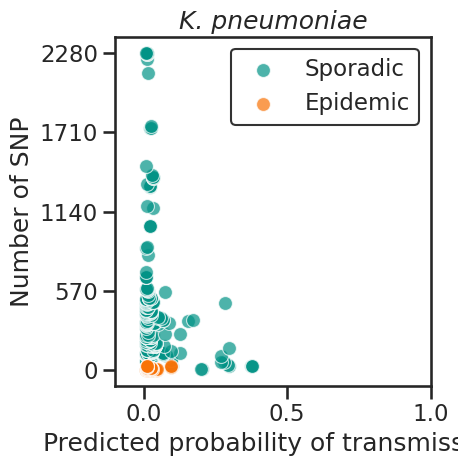

In [100]:
plot_transmission_snps(ttp, title="K. pneumoniae", sp="kp")